### Read Data and Import Necessary Libraries

In [5]:
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

conn = sqlite3.connect("../raw_data/sf_data.db")

query = "SELECT * FROM guild_tracking WHERE stat_type = 'Level'"
level_raw_data_df = pd.read_sql_query(query, conn)

conn.close()

### Level Progress

In [7]:
target_month = "2026-04" #yyyy-mm

level_raw_data_df = level_raw_data_df.drop_duplicates(subset=['player_name', 'timestamp'])
level_raw_data_df['timestamp'] = pd.to_datetime(level_raw_data_df['timestamp'])
pivot_df = level_raw_data_df.pivot(index='player_name', columns='timestamp', values='value')
weeks = sorted(pivot_df.columns)

# fill gaps in case of new players or players which left
pivot_df = pivot_df.ffill(axis=1).bfill(axis=1)

prog_df = pd.DataFrame(index=pivot_df.index)
monthly_prog_cols = []
last_level_col = None

# sort by month
monthly_df = pivot_df.T.resample('ME').last().T
months = monthly_df.columns
monthly_df.columns = [f"Level_{m.strftime('%Y-%m')}" for m in months]
final_df = monthly_df.copy()

# compute monthly progress
for i, week in enumerate(weeks):
    if week.strftime('%Y-%m') == target_month:
        last_level_col = week
    if i > 0:
        prev_week = weeks[i-1]
        if week.strftime('%Y-%m') == target_month:
            col_name = f'Prog_{prev_week.strftime("%Y-%m-%d")}_to_{week.strftime("%Y-%m-%d")}'
            prog_df[col_name] = pivot_df[week] - pivot_df[prev_week]
            monthly_prog_cols.append(col_name)

final_monthly_df = pd.DataFrame(index=pivot_df.index)
final_monthly_df[f'Level_End_{target_month}'] = pivot_df[last_level_col]

for col in monthly_prog_cols:
    final_monthly_df[col] = prog_df[col]

final_monthly_df[f'Monthly_Progress_{target_month}'] = prog_df[monthly_prog_cols].sum(axis=1)
final_monthly_df = final_monthly_df.reset_index().sort_values(by=f'Monthly_Progress_{target_month}', ascending=False)
print(final_monthly_df)

         player_name  Level_End_2026-04  Prog_2026-04-20_to_2026-04-27  \
35          Restless              444.0                            2.0   
43           Swagboi              448.0                            2.0   
46          Tecanite              407.0                            2.0   
5             Bluex3              493.0                            2.0   
47          Thorgrim              387.0                            2.0   
41         StupidHoe              458.0                            2.0   
50            Wutbob              509.0                            2.0   
22         Kampfbock              464.0                            1.0   
19      HER-WIEDZMIN              428.0                            1.0   
21            Jan284              411.0                            1.0   
24           Liiight              489.0                            1.0   
34            Raguos              454.0                            1.0   
40       Sigurlasius              468.

### Visualization

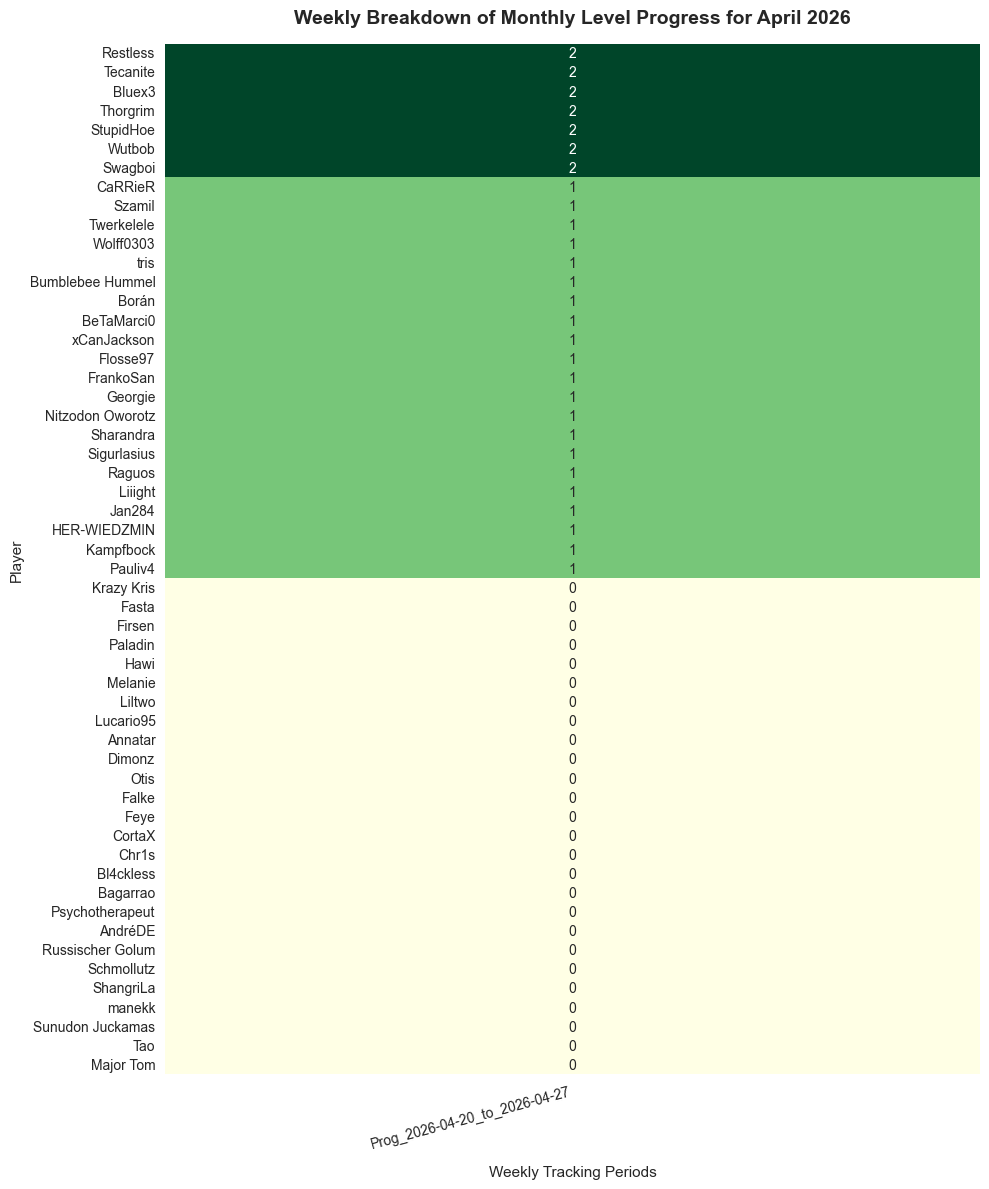

In [10]:
prog_cols = [c for c in final_monthly_df.columns if c.startswith("Prog_")]
final_monthly_df_sorted = final_monthly_df.sort_values(by=f'Monthly_Progress_{target_month}', ascending=False)
plot_data = final_monthly_df_sorted.set_index("player_name")[prog_cols]

fig, ax = plt.subplots(figsize=(10, 12))

sns.heatmap(plot_data,
            annot=True,
            fmt=".0f",
            cmap="YlGn",
            cbar_kws={"label": "Level Up"},
            cbar=False,
            ax=ax)

plt.title(f"Weekly Breakdown of Monthly Level Progress for April 2026", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Weekly Tracking Periods", fontsize=11, labelpad=10)
plt.ylabel("Player", fontsize=11)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()

save_path = f"../visualizations/Q2_2026/monthly_analyses/monthly_level_progress_april_2026.png" #change accordingly
plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()